# Cape Cauldron coherent vortices

The Cape Cauldron is the Agulhas-ring corridor south-west of South Africa.
Haller & Beron-Vera (2013,
[doi:10.1017/jfm.2013.391](https://doi.org/10.1017/jfm.2013.391)) found
coherent Lagrangian vortices there with the construction this notebook uses.

The FTLE ridges of `cabo_verde_ftle` mark hyperbolic stretching. A coherent
Lagrangian vortex is a region that stays together as it advects, bounded by a
material loop that stretches uniformly. From the same Cauchy–Green tensor
$C = (\nabla F)^\top \nabla F$, with eigenpairs $C\xi_i = \lambda_i \xi_i$ and
$0 < \lambda_1 \le \lambda_2$, Haller & Beron-Vera (2013, Eq. 14) build the
direction fields

$$
\eta_\lambda^{\pm} = \sqrt{\frac{\lambda_2 - \lambda^2}{\lambda_2 - \lambda_1}}\,\xi_1
  \;\pm\; \sqrt{\frac{\lambda^2 - \lambda_1}{\lambda_2 - \lambda_1}}\,\xi_2 \,,
$$

defined where $\lambda_1 < \lambda^2 < \lambda_2$. They satisfy
$|\nabla F\,\eta_\lambda| = \lambda$ at every point, so a curve tangent to one
has its arc length multiplied by $\lambda$ over the window. A closed curve
tangent to one is a *closed shear line*. Each vortex holds a nested family of
them over $\lambda$, and the outermost member is its boundary.

`closed_shear_lines` finds them with the return map of Haller & Beron-Vera
(2013). Lines are launched along a short section from a candidate centre and
traced until they cross it again, and a launch that comes back to itself is a
closed orbit.

In [1]:
# Importing Parcels pulls in the holoviews/bokeh bootstrap and prints an
# alpha-version notice, neither of which belongs on the rendered page.
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from parcels import FieldSet, Particle, ParticleSet, StatusCode
from parcels.convert import copernicusmarine_to_sgrid
from parcels.kernels import AdvectionRK4

from lcs_parcels import (
    NeighborSeedGrid,
    closed_shear_lines,
    elliptic_centres,
    outermost_shear_lines,
    stretch_range,
)

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_87614/2914286310.py:6: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, Particle, ParticleSet, StatusCode


## Currents

Hourly CMEMS surface currents at 1/12 degree, the local file that `get_data`
writes.

In [2]:
currents = xr.open_dataset("data/cape_cauldron_currents_hourly.nc").load()
currents

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 1489, depth: 1, latitude: 385, longitude: 433)
Coordinates:
  * time       (time) datetime64[ns] 12kB 2025-05-31 ... 2025-08-01
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 2kB -52.0 -51.92 -51.83 ... -20.08 -20.0
  * longitude  (longitude) float32 2kB -6.0 -5.917 -5.833 ... 29.83 29.92 30.0
Data variables:
    uo         (time, depth, latitude, longitude) float32 993MB 0.1821 ... nan
    vo         (time, depth, latitude, longitude) float32 993MB 0.2285 ... nan
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     hourly mean fields from Global Ocean Physics A...
    copernicusmarine_version:  2.4.1

## Parcels v4 field set

`copernicusmarine_to_sgrid` tags the CMEMS A-grid with SGRID metadata, and
`from_sgrid_conventions` wraps it as a spherical `FieldSet`.

In [3]:
sgrid = copernicusmarine_to_sgrid(fields={"U": currents["uo"], "V": currents["vo"]})
fieldset = FieldSet.from_sgrid_conventions(sgrid, mesh="spherical")
z_surface = float(currents["depth"].values[0])

## Seed grid and window

A box across the Cape Cauldron at 1/25 degree, released on 2025-06-01 and read
at 30 days. An Agulhas ring turns once in roughly 7 to 12 days, so the window
covers a few revolutions. A vortex boundary belongs to one window, so only the
forward flow map is needed.

In [4]:
t0 = np.datetime64("2025-06-01")
T = np.timedelta64(30, "D")
lon_axis = np.arange(2.0, 22.0 + 1e-9, 1 / 25)
lat_axis = np.arange(-44.0, -28.0 + 1e-9, 1 / 25)
seed = NeighborSeedGrid.from_axes(lon=lon_axis, lat=lat_axis)
seed

<NeighborSeedGrid 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00>

## Recovery kernel

Particles that leave the domain or hit land are turned into `NaN` in place
(Parcels would otherwise abort the run), so losses propagate as `NaN`
through every diagnostic below. The kernel sets `StatusCode.EndofLoop`
rather than `StatusCode.Delete`, because deleting shrinks the particle
array and breaks the alignment with the seed order.

In [5]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)

## Advect forward

In [6]:
lon, lat = seed.to_parcels_pset()
z = np.full(len(lon), z_surface)
pset = ParticleSet(fieldset, pclass=Particle, x=lon, y=lat, z=z, t=t0)
pset.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=T,
    verbose_progress=False,
)

In [7]:
forward = seed.pset_to_flowmap(lon=pset.x, lat=pset.y, t0=t0, t1=t0 + T)
forward

<NeighborFlowMap 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00,
                 t0 2025-06-01T00:00:00, T +30.0 days>

A second run over the first day gives the rotation of the flow. The polar
rotation angle is defined modulo $2\pi$, and an Agulhas ring turns several
times in 30 days, so its sign gives the rotation sense only over a short
window.

In [8]:
pset_day = ParticleSet(fieldset, pclass=Particle, x=lon, y=lat, z=z, t=t0)
pset_day.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=np.timedelta64(1, "D"),
    verbose_progress=False,
)
first_day = seed.pset_to_flowmap(
    lon=pset_day.x, lat=pset_day.y, t0=t0, t1=t0 + np.timedelta64(1, "D")
)
first_day

<NeighborFlowMap 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00,
                 t0 2025-06-01T00:00:00, T +1.0 days>

Particles lost to land or to the domain edge over the 30 days.

In [9]:
int(np.isnan(np.asarray(pset.x)).sum())

24500

## Eigendecomposition and FTLE

The FTLE is the backdrop the centres and the boundaries are drawn on below.

In [10]:
eigen = forward.cg_eigen()
eigen

<xarray.Dataset> Size: 13MB
Dimensions:   (i: 501, j: 401, eig: 2, comp: 2)
Coordinates:
  * i         (i) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499 500
  * j         (j) int64 3kB 0 1 2 3 4 5 6 7 ... 393 394 395 396 397 398 399 400
    lon_grid  (i, j) float64 2MB 2.0 2.0 2.0 2.0 2.0 ... 22.0 22.0 22.0 22.0
    lat_grid  (i, j) float64 2MB -44.0 -43.96 -43.92 ... -28.08 -28.04 -28.0
  * eig       (eig) int64 16B 0 1
  * comp      (comp) <U1 8B 'x' 'y'
    t0        datetime64[s] 8B 2025-06-01
    T         timedelta64[s] 8B 30 days
Data variables:
    lambda    (i, j, eig) float64 3MB nan nan nan nan nan ... nan nan nan nan
    xi        (i, j, comp, eig) float64 6MB nan nan nan nan ... nan nan nan nan

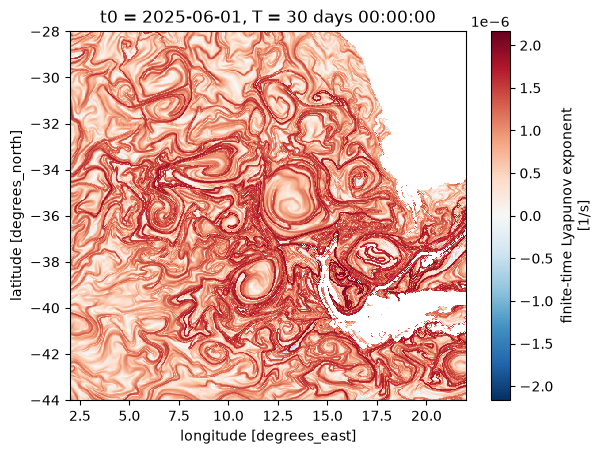

In [11]:
ftle = forward.ftle()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid")

## Where $\eta_\lambda$ exists, at $\lambda = 1$

$\eta_1$ needs $\lambda_1 < 1 < \lambda_2$, a neighbourhood stretched along one
eigendirection and contracted along the other. Where that fails, no direction
has a stretching factor of 1, and a traced line ends.

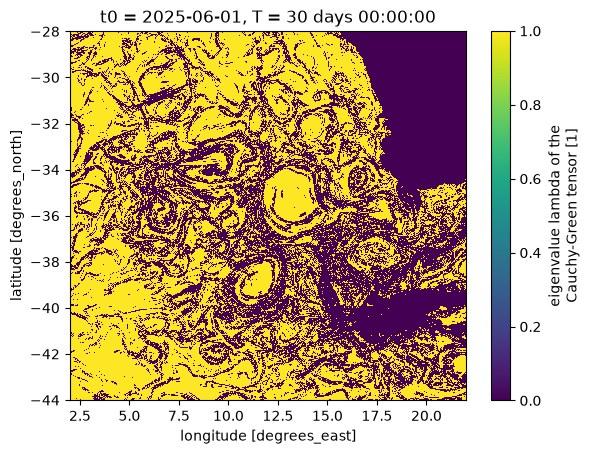

In [12]:
lambda1 = eigen["lambda"].isel(eig=0)
lambda2 = eigen["lambda"].isel(eig=1)
((lambda1 < 1.0) & (1.0 < lambda2)).plot.pcolormesh(x="lon_grid", y="lat_grid")

## How far from area-preserving

$|\det \nabla F| = \sqrt{\lambda_1\lambda_2}$ is the area change of a grid cell
over the window. A loop whose interior changes area by $J$ and keeps its shape
changes its length by $\sqrt{J}$, so a boundary closes near
$\lambda = \sqrt{J}$ rather than at 1, and the search scans a range of
$\lambda$.

In [13]:
np.sqrt(lambda1 * lambda2).quantile([0.05, 0.25, 0.5, 0.75, 0.95])

<xarray.DataArray 'lambda' (quantile: 5)> Size: 40B
array([1.72273788e-01, 9.35690458e-01, 4.95873883e+00, 5.15097163e+01,
       6.74995378e+02])
Coordinates:
  * quantile  (quantile) float64 40B 0.05 0.25 0.5 0.75 0.95
Attributes:
    long_name:  eigenvalue lambda of the Cauchy-Green tensor
    units:      1

## Candidate centres

Windowed minima of $\lambda_2 / \lambda_1$, the points where the
eigendirections come closest to undefined, over a 100 km window and at least
50 km from the domain edge and from land.

In [14]:
anisotropy = (lambda2 / lambda1).assign_attrs(
    long_name="Cauchy-Green eigenvalue ratio", units="1"
)
centres = elliptic_centres(anisotropy, extremum="min", window_m=100_000.0)
centres

<xarray.Dataset> Size: 5kB
Dimensions:  (centre: 227)
Coordinates:
  * centre   (centre) int64 2kB 0 1 2 3 4 5 6 7 ... 220 221 222 223 224 225 226
Data variables:
    lon      (centre) float64 2kB 2.72 2.88 2.88 2.96 ... 20.56 20.92 21.16
    lat      (centre) float64 2kB -43.12 -39.88 -38.8 ... -42.24 -43.24 -42.08
Attributes:
    extremum:          min
    edge_m:            50000.0
    edge_cells_i:      14
    edge_cells_j:      12
    window_m:          100000.0
    window_cells_i:    27
    window_cells_j:    21
    grid_spacing_i_m:  3598.343413748942
    grid_spacing_j_m:  4447.797065782255

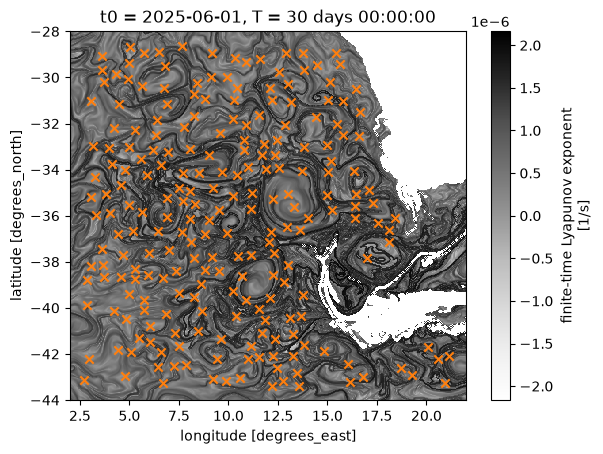

In [15]:
_, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys")
ax.scatter(centres["lon"], centres["lat"], marker="x", color="tab:orange")
plt.show()

## The scan over $\lambda$

`stretch_range` is the default scan, log-symmetric about 1 from $1/1.5$ to
$1.5$ in steps of 0.03 in $\ln \lambda$, so divergence and convergence are
bracketed alike.

In [16]:
stretches = stretch_range(stretch_max=1.5, step=0.03)
stretches

array([0.67705687, 0.69767633, 0.71892373, 0.74081822, 0.76337949,
       0.78662786, 0.81058425, 0.83527021, 0.86070798, 0.88692044,
       0.91393119, 0.94176453, 0.97044553, 1.        , 1.03045453,
       1.06183655, 1.09417428, 1.12749685, 1.16183424, 1.19721736,
       1.23367806, 1.27124915, 1.30996445, 1.34985881, 1.39096813,
       1.43332941, 1.47698079])

## Closed shear lines

Every closed orbit at every centre, stretching factor and branch, from two
sections running 150 km due east and due west of each centre.

In [17]:
orbits = closed_shear_lines(
    forward,
    centre_lon=centres["lon"],
    centre_lat=centres["lat"],
    stretches=stretches,
    max_radius_m=150_000.0,
)
orbits

<xarray.Dataset> Size: 63kB
Dimensions:     (orbit: 25, point: 151)
Coordinates:
  * orbit       (orbit) int64 200B 0 1 2 3 4 5 6 7 8 ... 17 18 19 20 21 22 23 24
  * point       (point) int64 1kB 0 1 2 3 4 5 6 ... 144 145 146 147 148 149 150
Data variables:
    lon         (orbit, point) float64 30kB 13.56 13.56 13.55 ... 12.79 12.8
    lat         (orbit, point) float64 30kB -35.64 -35.62 ... -35.64 -35.64
    centre      (orbit) int64 200B 177 177 177 177 177 ... 177 177 177 177 177
    centre_lon  (orbit) float64 200B 13.32 13.32 13.32 ... 13.32 13.32 13.32
    centre_lat  (orbit) float64 200B -35.64 -35.64 -35.64 ... -35.64 -35.64
    stretch     (orbit) float64 200B 1.162 1.162 1.197 1.197 ... 1.31 1.31 1.35
    branch      (orbit) int64 200B 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
    area_m2     (orbit) float64 200B 2.364e+09 3.092e+09 ... 5.039e+09 5.315e+09
    radius_m    (orbit) float64 200B 2.743e+04 3.137e+04 ... 4.005e+04 4.113e+04
    residual_m  (orbit) float64 200B 1.257e+03 1.093e+03 ... 576.3 1.096e+03
Attributes:
    stretch_min:       0.6770568744981647
    stretch_max:       1.4769807938826427
    n_stretch:         27
    max_radius_m:      150000.0
    launch_spacing_m:  3598.343413748942
    step_m:            1799.171706874471
    closure_tol_m:     1799.171706874471
    n_centres:         227
    n_never_returned:  24455

Each orbit's equivalent radius against the $\lambda$ it closed at. One vortex
shows up as a run of orbits growing with $\lambda$.

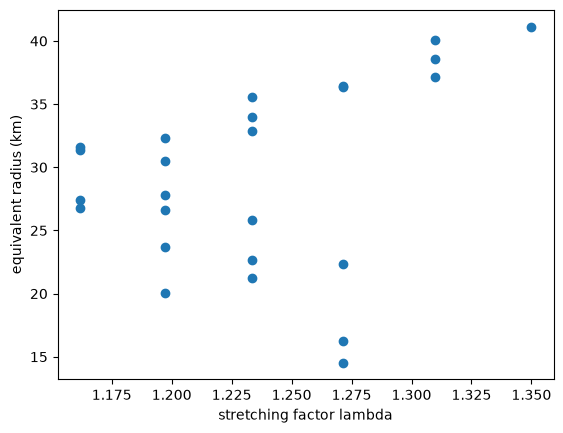

In [18]:
_, ax = plt.subplots()
ax.scatter(orbits["stretch"], orbits["radius_m"] / 1000)
ax.set_xlabel("stretching factor lambda")
ax.set_ylabel("equivalent radius (km)")
plt.show()

## The outermost boundary per vortex

`outermost_shear_lines` keeps the largest orbit per centre and merges centres
that one boundary encloses. `rotation_sense` is the sign of the first day's
polar rotation angle inside the boundary, counter-clockwise positive. South of
the equator a clockwise eddy is cyclonic.

In [19]:
eddies = outermost_shear_lines(orbits, rotation=first_day.polar_rotation())
eddies

<xarray.Dataset> Size: 4kB
Dimensions:         (eddy: 1, point: 151)
Coordinates:
  * eddy            (eddy) int64 8B 0
    orbit_index     (eddy) int64 8B 24
  * point           (point) int64 1kB 0 1 2 3 4 5 6 ... 145 146 147 148 149 150
Data variables: (12/13)
    lon             (eddy, point) float64 1kB 12.8 12.79 12.79 ... 12.79 12.8
    lat             (eddy, point) float64 1kB -35.64 -35.63 ... -35.64 -35.64
    centre          (eddy) int64 8B 177
    centre_lon      (eddy) float64 8B 13.32
    centre_lat      (eddy) float64 8B -35.64
    stretch         (eddy) float64 8B 1.35
    ...              ...
    area_m2         (eddy) float64 8B 5.315e+09
    radius_m        (eddy) float64 8B 4.113e+04
    residual_m      (eddy) float64 8B 1.096e+03
    centroid_lon    (eddy) float64 8B 13.28
    centroid_lat    (eddy) float64 8B -35.64
    rotation_sense  (eddy) int64 8B 1
Attributes:
    stretch_min:            0.6770568744981647
    stretch_max:            1.4769807938826427
    n_stretch:              27
    max_radius_m:           150000.0
    launch_spacing_m:       3598.343413748942
    step_m:                 1799.171706874471
    closure_tol_m:          1799.171706874471
    n_centres:              227
    n_never_returned:       24455
    n_orbits_in:            25
    n_centres_with_orbits:  1

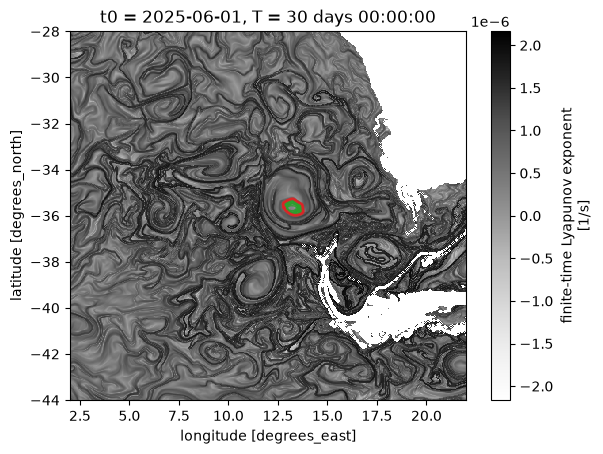

In [20]:
_, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys")
ax.plot(orbits["lon"].T, orbits["lat"].T, color="tab:green", lw=0.5)
ax.plot(eddies["lon"].T, eddies["lat"].T, color="tab:red", lw=2.0)
plt.show()

## The polar rotation angle

The rotation over the first day, which $C$ discards, with the boundaries on
top.

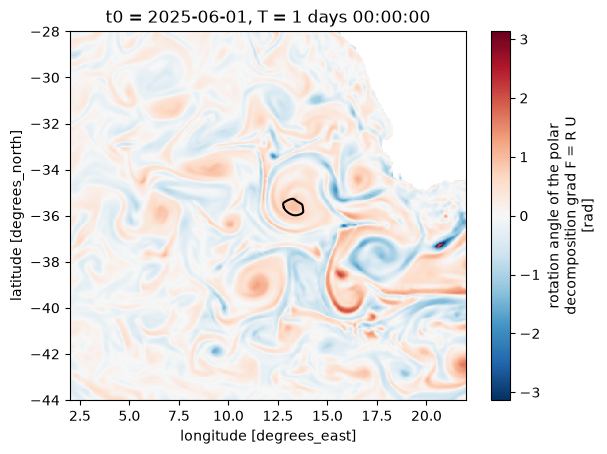

In [21]:
_, ax = plt.subplots()
first_day.polar_rotation().plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax)
ax.plot(eddies["lon"].T, eddies["lat"].T, color="black", lw=1.5)
plt.show()

## Material check

A boundary stretches every tangent element by its $\lambda$, so its arc length
over the window should grow by that factor. `forward.image` carries a curve
through the flow map already computed, with no second Parcels run. A circle of
the same equivalent radius about the same centre is not tangent to
$\eta_\lambda$, so nothing constrains its ratio.

In [22]:
def arc_length_m(curve):
    lon, lat = curve["lon"], curve["lat"]
    lat_mid = np.deg2rad(0.5 * (lat + lat.shift(point=-1)))
    dx = 6_371_000.0 * np.cos(lat_mid) * np.deg2rad(lon.shift(point=-1) - lon)
    dy = 6_371_000.0 * np.deg2rad(lat.shift(point=-1) - lat)
    return np.hypot(dx, dy).sum("point")


boundary = eddies.isel(eddy=0)
evolved = forward.image(lon_0=boundary["lon"], lat_0=boundary["lat"])

angle = xr.DataArray(np.linspace(0.0, 2 * np.pi, 361), dims="point")
radius_deg = boundary["radius_m"] / 111_195.0
circle = xr.Dataset(
    {
        "lon": boundary["centroid_lon"]
        + radius_deg * np.cos(angle) / np.cos(np.deg2rad(boundary["centroid_lat"])),
        "lat": boundary["centroid_lat"] + radius_deg * np.sin(angle),
    }
)
evolved_circle = forward.image(lon_0=circle["lon"], lat_0=circle["lat"])

The boundary's $\lambda$, its arc-length ratio, and the circle's.

In [23]:
(
    float(boundary["stretch"]),
    float(arc_length_m(evolved) / arc_length_m(boundary)),
    float(arc_length_m(evolved_circle) / arc_length_m(circle)),
)

(1.3498588075760032, 1.2977952986181571, 1.5497847709947365)

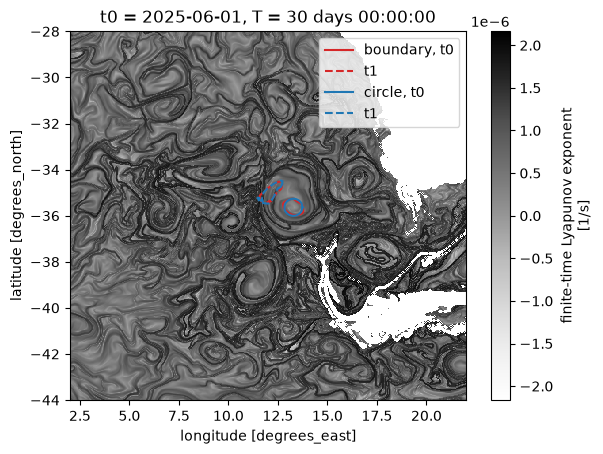

In [24]:
_, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys")
ax.plot(boundary["lon"].T, boundary["lat"].T, color="tab:red", label="boundary, t0")
ax.plot(evolved["lon"].T, evolved["lat"].T, color="tab:red", ls="--", label="t1")
ax.plot(circle["lon"].T, circle["lat"].T, color="tab:blue", label="circle, t0")
ax.plot(
    evolved_circle["lon"].T,
    evolved_circle["lat"].T,
    color="tab:blue",
    ls="--",
    label="t1",
)
ax.legend()
plt.show()

## Outcome

Of the 501 by 401 seeded particles, 24500 are lost to land or the domain edge.
$|\det \nabla F|$ runs from 0.172 at the 5 percent quantile to 675 at the 95
percent, with a median of 4.96.

The search over 227 candidate centres closes 25 orbits, all at one centre,
13.32 E 35.64 S. The outermost one is the single boundary, at
$\lambda = 1.350$ with an equivalent radius of 41.1 km and its centroid at
13.28 E 35.64 S. Over the first day it turns counter-clockwise, which south of
the equator is anticyclonic.

Carried through the flow map, the boundary's arc length grows by 1.298
against its $\lambda$ of 1.350. A circle of the same equivalent radius about
the same centroid grows by 1.550.